In [9]:
# Task 1: Import Required Libraries


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set plot style
sns.set_style("whitegrid")


In [10]:
# Task 2: Load and Explore Dataset


# Load dataset
df = pd.read_csv(r"C:\Users\RUDZANI   NETHENGWE\Downloads\Medical Insurance Dataset\insurance.csv")

# Display first rows
print("First 5 rows of dataset:")
print(df.head())

# Dataset structure
print("\nDataset Info:")
print(df.info())

# Summary statistics
print("\nSummary Statistics:")
print(df.describe())

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Number of records
print("\nDataset Shape:", df.shape)



First 5 rows of dataset:
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None

Summary Statistics:
               age          bm

TASK 2
The Medical insurance dataset contains 7 columns with headings age, sex, bmi, children, smoker, region, and charges. it has 1338 rows. The age column represents the age of the client, the sex column represents the gender of the client, bmi means body mass index of the client, the children column represents the number of children/ dependents the client has, the smoker column tells us the smoking status of the client, the region column tells us the geographical region of the client, lastly the charges column represents the medial insurance costs. 

Total records: there are 1338 entries (indeexed from 0-1337)
total columns: 7
columns with numerical data (4): age, bmi, children, and charges
columns with catagorical data (3): sex, smoker, and region
DataType: 
age column contains 64 integers 
sex column contains object datatype
bmi column contains 64 float 
childrent column contains 64 integers
smoker column contains object datatype
region column contains object datatype
charges column contains 64 float 

Missing values:
according to the Non-Null count column in df.info() output, the dataset is completely clean regarding null values, every single column shows a count of 1338 non-null, which matches the total number of entries. 

Statistical summary: 
ages range from 18 to 64 years, with 39 as the average age. The range for bmi is 15.96 - 53.13, and the average of bmi is 30.66 which falls into obese category according to the standard BMI scales. The Medical insurances charges range from 1121 to 63770

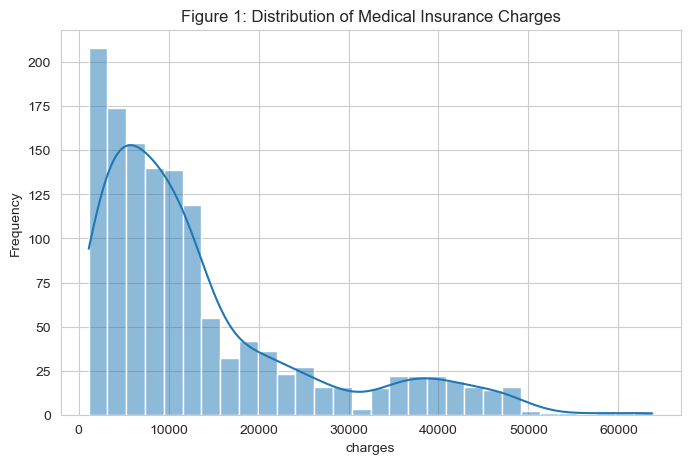

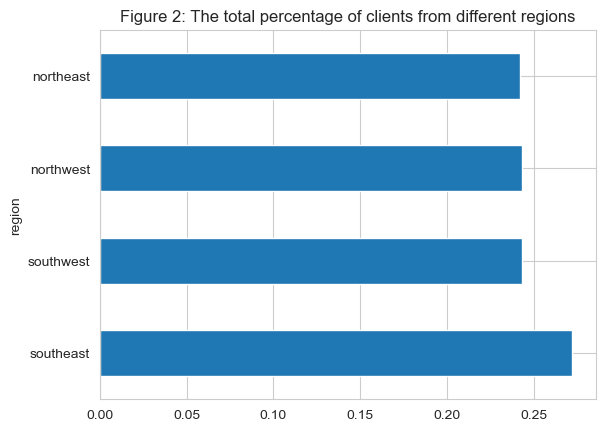

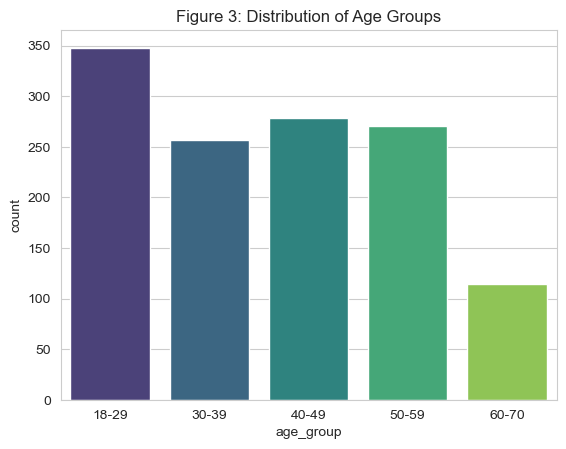

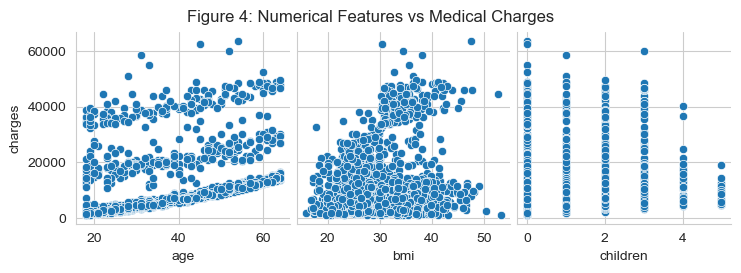

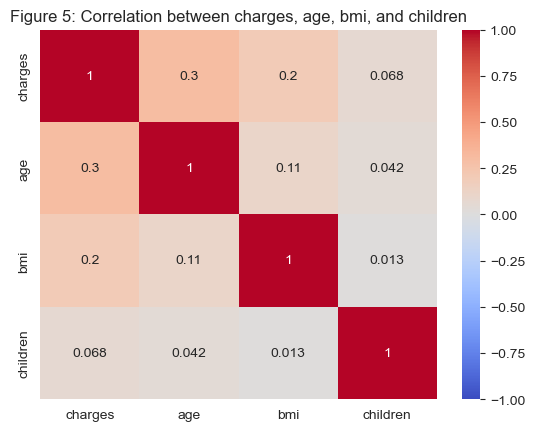

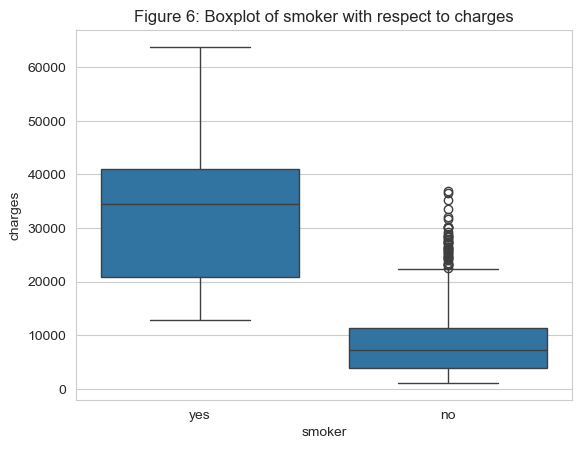

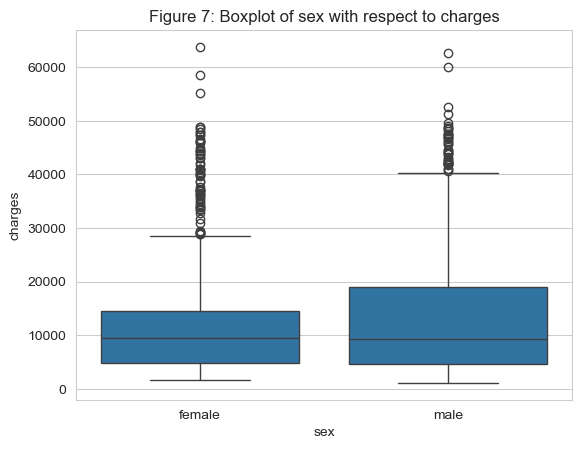

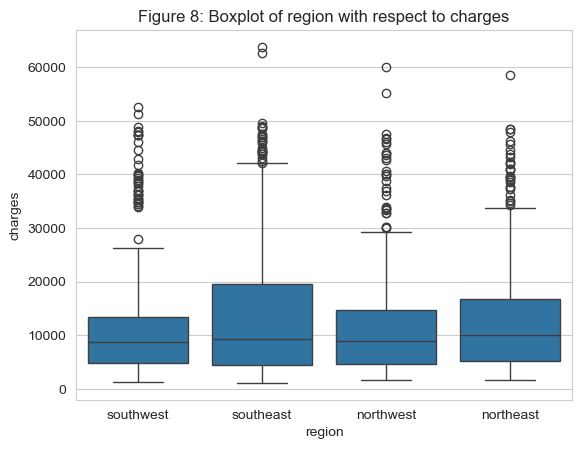

In [17]:
# Task 3: Exploratory Data Analysis (EDA)


#distribution of charges 
#create a new matplotlib figure with a size of 8 inches wide and 5 inches tall
plt.figure(figsize=(8,5))
#use sns to draw histogram of the charges column, kernel density estimate (kde)=True adds a smooth curve over the histogram to show data distribution. 
sns.histplot(df['charges'],kde=True)
plt.title("Figure 1: Distribution of Medical Insurance Charges")
plt.xlabel("charges")
plt.ylabel("Frequency")
plt.show()

#Univariate analysis 

#Lets calculate the percentage of each region category 
df.region.value_counts(normalize=True)

#plot the bar graph of percentage region catagories 
df.region.value_counts(normalize=True).plot.barh()
plt.title('Figure 2: The total percentage of clients from different regions')
plt.show()

#create age groups in 10-year increments 
#to protect origional data create a deep copy, it breaks a link to the origional data. 
df_analysis=df[df['age']>18].copy()
bins=[18, 30, 40, 50, 60, 70]
labels= ['18-29', '30-39', '40-49', '50-59', '60-70']
df_analysis['age_group']=pd.cut(df_analysis['age'], bins=bins, labels=labels, right=False)

#now perform univariate analysis 
sns.countplot(x='age_group', hue='age_group', data=df_analysis, palette='viridis', legend=False)
plt.title('Figure 3: Distribution of Age Groups')
plt.show()

#Bivariate analysis 

#Numeric-numerical analysis

#pair plot
numeric_cols=['age', 'bmi', 'children']
sns.pairplot(df, x_vars=numeric_cols, y_vars='charges', kind='scatter')
plt.suptitle('Figure 4: Numerical Features vs Medical Charges', y=1.05)
plt.show()

#creating a matrix using charges, age, bmi, children as rows and columns
df[['charges', 'age', 'bmi', 'children']].corr()

#plot the correlation matrix of charges, age, bmi, children in df dataframe
sns.heatmap(df[['charges', 'age', 'bmi', 'children']].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Figure 5: Correlation between charges, age, bmi, and children')
plt.show()

#Numeric-catagorical analysis 

#groupby the smokers to find the statistical analysis of the charges with response no & yes separately.
df.groupby('smoker')['charges'].median()

#plot the box of charges with response(smoker) no & yes.
sns.boxplot(x=df['smoker'], y=df['charges'])
plt.title('Figure 6: Boxplot of smoker with respect to charges')
plt.show()

#groupby the sex to find the statistical analysis of the charges with response male & female separately.
df.groupby('sex')['charges'].median()

#plot the box of charges with response(sex) female & male.
sns.boxplot(x=df['sex'], y=df['charges'])
plt.title('Figure 7: Boxplot of sex with respect to charges')
plt.show()

#groupby the region to find the statistical analysis of the charges 
df.groupby('region')['charges'].median()

#plot the box of charges with the responses of region.
sns.boxplot(x=df['region'], y=df['charges'])
plt.title('Figure 8: Boxplot of region with respect to charges')
plt.show()

TASK 3: 

Distribution of Medical Insurance Charges:
The graph is *skewed to the right* (positively skewed). That means most people have relatively low charges (the left side of the graph is tall), while only a few have very high charges (the right tail stretches out). The highest bar is near the 0–10,000 charge range. This indicates the most common charge values are in that interval – lots of claims are for amounts less than 10,000.  As charges go above 10,000, the bars get shorter, meaning fewer and fewer observations have those higher values. By the time you get to 50,000–60,000, the frequency is almost zero. The data suggests insurance claims are typically small, with occasional large outliers. Models or analyses should account for this skewness (e.g., using log‑transformation or robust methods).

patterns in Data 
Univariate analysis: Figure 2 shows that region Southeast has most clients, and figure 3 shows that the mediacal insurance is mostly joined by clients aged 18-29. 
Bivariate analysis: Figure 4 shows charges tend to increase with age, although the relationship looks roughly linear with some spread. Higher bmi is associated with higher charges, the spread is wider, indicating bmi's effect is less strong or more variable that age's. Median charges appear slightly higher for individuals with more children but the trend is less clear than with age and bmi. Figure 6 tells us clients that smoke have charges ranging from $ 22000-42000, with a median of $ 34456.34845, which is more than of the ones that dont smoke. Figure 7 shows males are charged from $1100-20000 with a median of $9369.61575, the other points are outliers, females are charged $1600-15000 witha median of $9412.96250, the other points are outliers according to the boxplot, the medians and distributions between the two genders are almost similar, meaning theres no much difference.Figure 8 shows that some southeast region clients might be charged more because it has a higher max charge than the other regions, the charges at southeast region range from $1100-19000, and has a median of $9294.131950, the other points outside the box are outliers, but the medians of all regions are all almost similar. 

which variables influence charges:
Figure 5 shows correlation matrix between charges, age, bmi, and children. Charges vs age has 0.3 diagonal value resulting in weak positive correlation, as age increases, charges tend to rise a little. Charges vs bmi has 0.2, resulting in a weak positive correlation, higher bmi is linked to slightly higher charges. charges vs children has 0.068, this is a very weak positive correlation, the number of children has almost no linear effect on charges. Therefore smoker has high influence, age has medium-high influence, bmi has medium influence, children has low influence, region and sex have very low influence. 

In [ ]:
# Task 4: Data Preprocessing


# Convert categorical variables to numeric using dummy variables
df_encoded = pd.get_dummies(df, drop_first=True)

print("\nEncoded Dataset Preview:")
print(df_encoded.head())

TASK 4

Categorical features such as sex, smoker, and region were converted to numerical values because machine learning algorithms require numeric inputs.

In [18]:
# Task 5: Define Features and Target Variable


X = df_encoded.drop("charges", axis=1)
y = df_encoded["charges"]

TASK 5 
Charges is the target variable 

In [14]:
# Task 6: Split Dataset


X_train, X_test, y_train, y_test = train_test_split(
X, y,
test_size=0.2,
random_state=42
)

print("\nTraining set size:", X_train.shape)
print("Testing set size:", X_test.shape)


Training set size: (1070, 8)
Testing set size: (268, 8)


TASK 6
The data was split in to test dataset(20%) and train data set(80%)

In [15]:
# Task 7: Train Linear Regression Model


model = LinearRegression()

model.fit(X_train, y_train)

print("\nModel training completed.")


Model training completed.


TASK 7
The linear regression model is trained on the training dataset (X_train, y_train)

In [19]:
# Task 8: Make Predictions


y_pred = model.predict(X_test)

print("\nFirst 10 Predictions:")
print(y_pred[:10])


First 10 Predictions:
[ 8969.55027444  7068.74744287 36858.41091155  9454.67850053
 26973.17345656 10864.11316424   170.28084136 16903.45028662
  1092.43093614 11218.34318352]


In [20]:
# Task 9: Evaluate Model Performance


mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation Metrics")

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R2 Score:", r2)



Model Evaluation Metrics
Mean Absolute Error (MAE): 4181.19447375365
Mean Squared Error (MSE): 33596915.85136145
Root Mean Squared Error (RMSE): 5796.284659276273
R2 Score: 0.7835929767120724



Actual vs Predicted:
      Actual Charges  Predicted Charges
764       9095.06825        8969.550274
887       5272.17580        7068.747443
890      29330.98315       36858.410912
1293      9301.89355        9454.678501
259      33750.29180       26973.173457


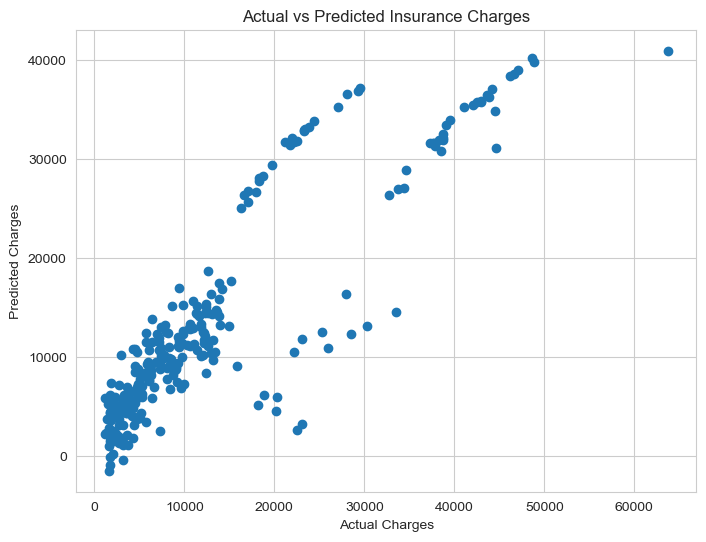

In [21]:
# Optional: Compare Actual vs Predicted


results = pd.DataFrame({
"Actual Charges": y_test,
"Predicted Charges": y_pred
})

print("\nActual vs Predicted:")
print(results.head())


# Plot actual vs predicted
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Insurance Charges")
plt.show()

Task 10: Reflection (Discussion)

1. Which variables most strongly influence medical insurance charges?
Based on the exploratory data analysis (EDA) and the model coefficients, the most influential variables are:

Smoker Status: This is the single most significant predictor. Smokers incur substantially higher charges than non-smokers.
Age: As age increases, medical insurance charges tend to rise linearly.
BMI (Body Mass Index): Higher BMI levels, especially when categorized as obese, show a strong correlation with increased medical costs.

2. Why might smoking affect insurance costs?
Smoking is a major health risk factor that leads to a higher probability of chronic diseases, such as cardiovascular issues, respiratory infections, and lung cancer. Because insurance is based on risk assessment, smokers are charged higher premiums to cover the statistically higher likelihood of expensive medical treatments and frequent healthcare utilization.

3. What improvements could be made to the model?
To improve the performance of this Linear Regression model, one could implement feature engineering by creating an interaction term between BMI and smoking status, as the combination of these two factors often leads to a non-linear spike in medical costs. Additionally, since some relationships in the data may not be perfectly linear, applying Polynomial Regression or non-linear algorithms like Random Forest or Gradient Boosting could help capture more complex patterns. The model’s accuracy could also be refined by identifying and handling outliers in the "charges" column, or by including additional demographic data such as pre-existing conditions or occupation if that data were available.
The r2 score was approximately 0.78 (or 78%) which indicates that the model has a strong predictive capability, explaining a significant majority of the variance in medical insurance charges. This means that factors like age, BMI, and smoking status are highly effective at capturing the trends in the data. While a score of 0.75 is quite high for a real-world medical dataset, the remaining 25% of unexplained variance(features that are not included) suggests that other individual factors—such as specific medical histories, genetic predispositions, and etc also play a role in determining final costs.